In [1]:
# Pipeline B – Classificazione (Multi-Asset)

#Obiettivo: Predire se il giorno successivo il titolo azionario salirà (1) o scenderà (0).

#Dataset: multi_assets_supervised.csv  
#Modello: Decision Tree Classifier  
#Split temporale: train (2015–2021), test (2022–oggi)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df_all = pd.read_csv(
    "../data/processed/multi_assets_supervised.csv",
    index_col=0,
    parse_dates=True
)

In [3]:
split_date = "2022-01-01"

train_all = df_all[df_all.index < split_date]
test_all  = df_all[df_all.index >= split_date]

In [4]:
features = ["Close", "Return"]

X_train_cls = train_all[features]
X_test_cls  = test_all[features]

y_train_cls = train_all["Target_Class"]
y_test_cls  = test_all["Target_Class"]

X_train_cls.shape, X_test_cls.shape

((8810, 2), (5005, 2))

In [5]:
clf = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

clf.fit(X_train_cls, y_train_cls)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
y_pred_cls = clf.predict(X_test_cls)

In [7]:
accuracy = accuracy_score(y_test_cls, y_pred_cls)
accuracy

0.5132867132867133

In [9]:
print(classification_report(y_test_cls, y_pred_cls))

              precision    recall  f1-score   support

           0       0.48      0.27      0.35      2383
           1       0.53      0.73      0.61      2622

    accuracy                           0.51      5005
   macro avg       0.50      0.50      0.48      5005
weighted avg       0.50      0.51      0.49      5005



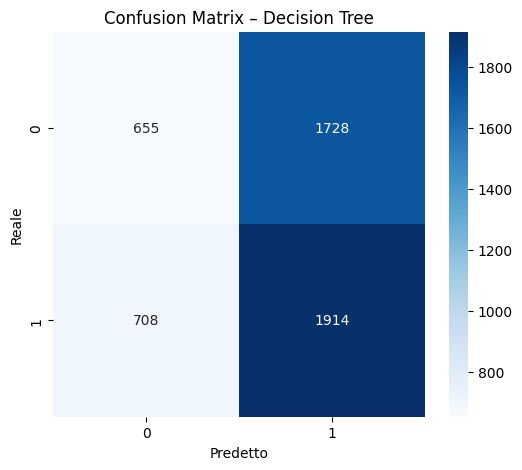

In [10]:
import seaborn as sns

cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Decision Tree")

plt.show()

In [11]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_cls, y_train_cls)

y_pred_nb = nb.predict(X_test_cls)

In [12]:
from sklearn.metrics import accuracy_score

accuracy_nb = accuracy_score(y_test_cls, y_pred_nb)
accuracy_nb

0.4995004995004995

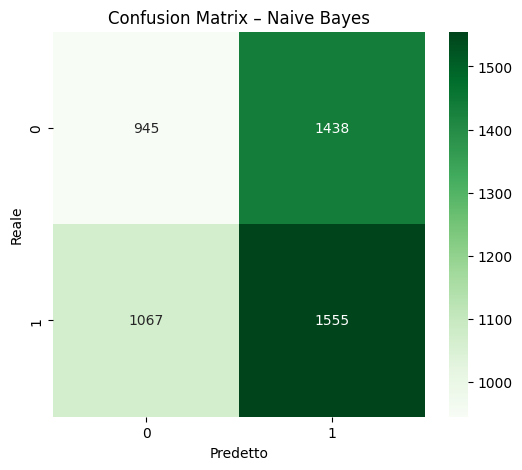

In [13]:
cm_nb = confusion_matrix(y_test_cls, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Naive Bayes")

plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test_cls, y_pred_nb))

              precision    recall  f1-score   support

           0       0.47      0.40      0.43      2383
           1       0.52      0.59      0.55      2622

    accuracy                           0.50      5005
   macro avg       0.49      0.49      0.49      5005
weighted avg       0.50      0.50      0.49      5005



In [15]:
accuracy_dt = accuracy_score(y_test_cls, y_pred_cls)

print("Accuracy Decision Tree:", accuracy_dt)
print("Accuracy Naive Bayes:", accuracy_nb)

Accuracy Decision Tree: 0.5132867132867133
Accuracy Naive Bayes: 0.4995004995004995


In [16]:
df_all = pd.read_csv(
    "../data/processed/multi_assets_supervised.csv",
    index_col=0,
    parse_dates=True
)

In [17]:
df_all = df_all.dropna()

In [18]:
df_all = df_all.sort_values(["Ticker", "Date"])

df_all["Return_lag1"] = df_all.groupby("Ticker")["Return"].shift(1)
df_all["Return_lag2"] = df_all.groupby("Ticker")["Return"].shift(2)
df_all["Return_lag3"] = df_all.groupby("Ticker")["Return"].shift(3)

df_all["Momentum_5"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x / x.shift(5) - 1)
df_all["Momentum_10"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x / x.shift(10) - 1)

df_all["MA_5"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x.rolling(5).mean())
df_all["MA_20"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())
df_all["MA_ratio"] = df_all["MA_5"] / df_all["MA_20"]

df_all["Volatility_10"] = df_all.groupby("Ticker")["Return"].transform(lambda x: x.rolling(10).std())

In [19]:
df_all = df_all.dropna()

In [20]:
split_date = "2022-01-01"

train_all = df_all[df_all.index < split_date]
test_all  = df_all[df_all.index >= split_date]

In [21]:
features = [
    "Return",
    "Return_lag1",
    "Return_lag2",
    "Return_lag3",
    "Momentum_5",
    "Momentum_10",
    "MA_ratio",
    "Volatility_10"
]

X_train_cls = train_all[features]
X_test_cls  = test_all[features]

y_train_cls = train_all["Target_Class"]
y_test_cls  = test_all["Target_Class"]

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

clf.fit(X_train_cls, y_train_cls)

y_pred_dt = clf.predict(X_test_cls)

accuracy_dt = accuracy_score(y_test_cls, y_pred_dt)
accuracy_dt

0.5226773226773227

In [23]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_cls, y_train_cls)

y_pred_nb = nb.predict(X_test_cls)

accuracy_nb = accuracy_score(y_test_cls, y_pred_nb)
accuracy_nb

0.5262737262737263

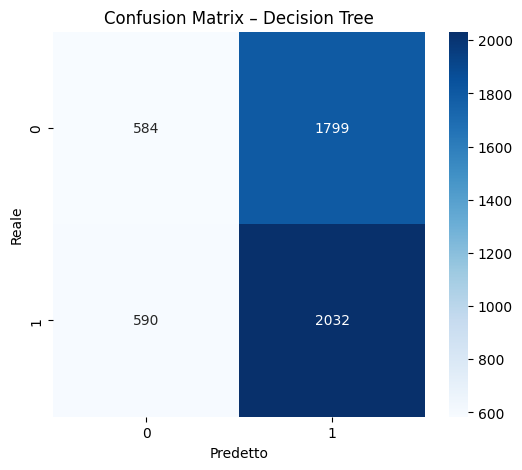

In [24]:
cm_dt = confusion_matrix(y_test_cls, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Decision Tree")
plt.show()

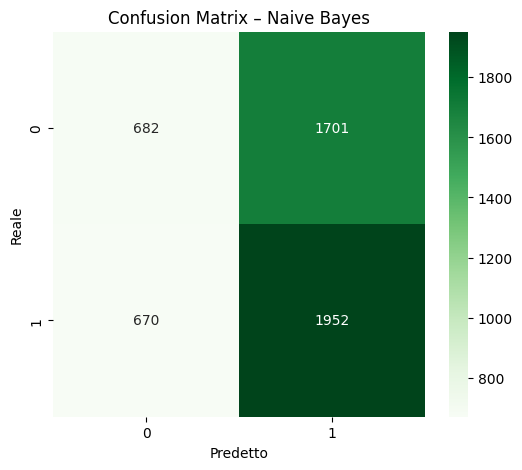

In [25]:
cm_nb = confusion_matrix(y_test_cls, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Naive Bayes")
plt.show()

In [26]:
clf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_cls, y_train_cls)

y_pred_rf = rf.predict(X_test_cls)

accuracy_rf = accuracy_score(y_test_cls, y_pred_rf)
accuracy_rf

0.5154845154845155

In [28]:
y_prob_rf = rf.predict_proba(X_test_cls)[:, 1]

In [29]:
threshold = 0.55
y_pred_custom = (y_prob_rf > threshold).astype(int)

accuracy_custom = accuracy_score(y_test_cls, y_pred_custom)
accuracy_custom

0.4993006993006993

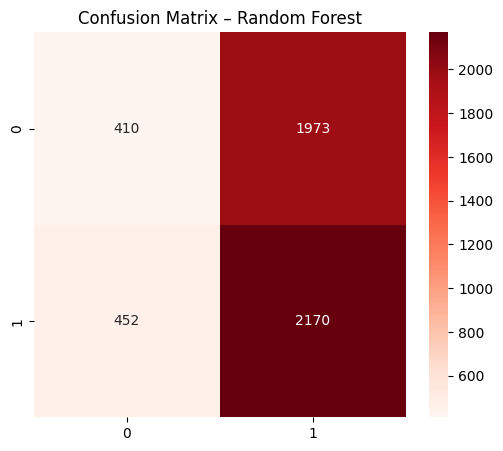

In [30]:
cm_rf = confusion_matrix(y_test_cls, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix – Random Forest")
plt.show()

In [31]:
import pandas as pd
import numpy as np

df_all = pd.read_csv(
    "../data/processed/multi_assets_threshold_002.csv",
    index_col=0,
    parse_dates=True
)

In [32]:
split_date = "2022-01-01"

train_all = df_all[df_all.index < split_date]
test_all  = df_all[df_all.index >= split_date]

In [33]:
features = [
    "Return",
    "Return_lag1",
    "Return_lag2",
    "Return_lag3",
    "Momentum_5",
    "Momentum_10",
    "MA_ratio",
    "Volatility_10"
]

X_train_cls = train_all[features]
X_test_cls  = test_all[features]

y_train_cls = train_all["Target_Class"]
y_test_cls  = test_all["Target_Class"]

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_cls, y_train_cls)

y_pred_rf = rf.predict(X_test_cls)

accuracy_rf = accuracy_score(y_test_cls, y_pred_rf)
accuracy_rf

0.5223813786929274

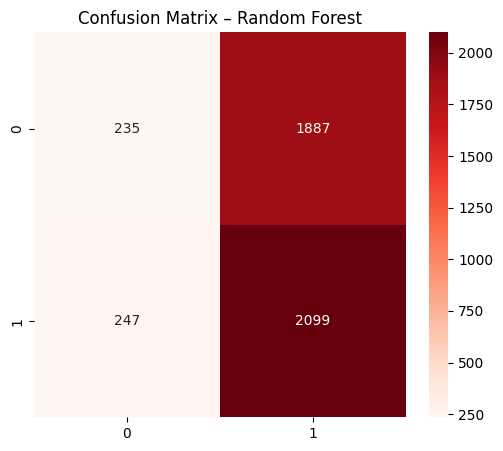

In [35]:
cm_rf = confusion_matrix(y_test_cls, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix – Random Forest")
plt.show()

In [36]:
import pandas as pd
import numpy as np

df_all = pd.read_csv(
    "../data/processed/multi_assets_threshold_001.csv",
    index_col=0,
    parse_dates=True
)

In [37]:
split_date = "2022-01-01"

train_all = df_all[df_all.index < split_date]
test_all  = df_all[df_all.index >= split_date]

In [38]:
df_all["Target_Class"].value_counts(normalize=True)

Target_Class
1.0    0.533841
0.0    0.466159
Name: proportion, dtype: float64

In [39]:
features = [
    "Return",
    "Return_lag1",
    "Return_lag2",
    "Return_lag3",
    "Momentum_5",
    "Momentum_10",
    "MA_ratio",
    "Volatility_10"
]

X_train_cls = train_all[features]
X_test_cls  = test_all[features]

y_train_cls = train_all["Target_Class"]
y_test_cls  = test_all["Target_Class"]

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_cls, y_train_cls)

y_pred_rf = rf.predict(X_test_cls)

accuracy_rf = accuracy_score(y_test_cls, y_pred_rf)
accuracy_rf

0.5238095238095238

In [41]:
df_all = pd.read_csv(
    "../data/processed/multi_assets_supervised.csv",
    index_col=0,
    parse_dates=True
)

In [42]:
split_date = "2022-01-01"

train_all = df_all[df_all.index < split_date]
test_all  = df_all[df_all.index >= split_date]

In [43]:
df_all = df_all.sort_values(["Ticker", "Date"])

df_all["Return_lag1"] = df_all.groupby("Ticker")["Return"].shift(1)
df_all["Return_lag2"] = df_all.groupby("Ticker")["Return"].shift(2)
df_all["Return_lag3"] = df_all.groupby("Ticker")["Return"].shift(3)

df_all["Momentum_5"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x / x.shift(5) - 1)
df_all["Momentum_10"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x / x.shift(10) - 1)

df_all["MA_5"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x.rolling(5).mean())
df_all["MA_20"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())
df_all["MA_ratio"] = df_all["MA_5"] / df_all["MA_20"]

df_all["Volatility_10"] = df_all.groupby("Ticker")["Return"].transform(lambda x: x.rolling(10).std())

In [44]:
df_all = df_all.dropna()

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_cls, y_train_cls)

y_pred_rf = rf.predict(X_test_cls)

accuracy_rf = accuracy_score(y_test_cls, y_pred_rf)
accuracy_rf

0.5238095238095238

In [46]:
clf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_cls, y_train_cls)

y_pred_rf = rf.predict(X_test_cls)

accuracy_rf = accuracy_score(y_test_cls, y_pred_rf)
accuracy_rf